In [ ]:
import pandas as pd

#read the aggregated beta values and metadata
df_betas = pd.read_csv('altumAge450k_beta.csv', index_col=0)
df_meta = pd.read_csv('altumAge450k_meta.csv', index_col=0)
df_meta.loc[['age', 'cancer'], :] = df_meta.loc[['age', 'cancer'], :].astype(float)

In [ ]:
#read in inflammation genes associated cgs
with open("../inflammation_HANNUM_with_proper_selection/cd_74_associated_cpgs.txt") as file:
    lines = file.read().splitlines()
cd_74_associated_cpgs_set=set(lines)

In [ ]:
#keep only the inflammation related cgs so the cd_74_associated_cpgs_set only
df_betas = df_betas[df_betas.index.isin(cd_74_associated_cpgs_set)] # 1097 cg site left

In [4]:
#set(list(df_cancer_meta.loc['tissue_type']))
females = df_meta.loc[:, df_meta.loc['gender'] == 'F']
females_c=females.loc[:,females.loc['cancer']==1]
females_no_c=females.loc[:,females.loc['cancer']==0]

males = df_meta.loc[:, df_meta.loc['gender'] == 'M']
males_c=males.loc[:,males.loc['cancer']==1]
males_no_c=males.loc[:,males.loc['cancer']==0]

all_cancer_meta=df_meta.loc[:,df_meta.loc['cancer']==1]
all_non_cancer_meta=df_meta.loc[:,df_meta.loc['cancer']==0]

In [5]:
import torch
from torch.utils.data import Dataset

#ELSO PARAMETER META MASODIK RAW
class MethylationDataset(Dataset):
    def __init__(self, meta_table, raw_table, transform=None):
        self.meta_table = meta_table
        self.raw_table = raw_table
        
    def __len__(self):
        return self.raw_table.shape[1]

    def __getitem__(self, idx):
        # Ensure the index is within the bounds of the meta_table
        if idx >= self.__len__():
            print('Index out of bounds:', idx)
            return -1

        # Extract the RNA data and age
        try:
            rna_data = self.raw_table.iloc[:, idx].tolist()
            age=float(self.meta_table.iloc[0,idx])
        except IndexError as e:
            print(f"IndexError: {e}, idx: {idx}")
            return -1
        return torch.tensor(rna_data), age
    
    def get_features_and_targets(self):
        features = []
        targets = []
        for idx in range(len(self)):
            rna_data, age = self[idx]
            features.append(rna_data.numpy())
            targets.append(age.numpy())
        return np.array(features), np.array(targets)
        

In [6]:
df_betas

,GSM927098,GSM1435226,GSM927136,GSM1258213,GSM1194476,GSM1429553,GSM1194434,GSM1429602,GSM1194449,GSM2062403,...,GSM1429594,GSM1429546,GSM2062409,GSM1194457,GSM1194371,GSM1194503,GSM1194413,GSM1429548,GSM1435240,GSM927111
cg00000884,0.860634,0.854010,0.822008,0.811222,0.853203,0.875249,0.840122,0.854442,0.796330,0.783799,...,0.793863,0.837399,0.770464,0.865052,0.795499,0.817674,0.845260,0.820549,0.875285,0.836259
cg00011994,0.063565,0.065346,0.070209,0.032097,0.068023,0.049314,0.046151,0.086767,0.067828,0.062046,...,0.045496,0.032960,0.089996,0.052224,0.064785,0.057450,0.057671,0.043890,0.052242,0.061687
cg00099091,0.122836,0.157132,0.162982,0.133659,0.129171,0.116851,0.123623,0.139540,0.103339,0.177318,...,0.096591,0.148734,0.204903,0.136596,0.092267,0.130578,0.121546,0.143357,0.158671,0.141786
cg00108454,0.499075,0.400726,0.499768,0.418299,0.410100,0.569224,0.466030,0.433841,0.356910,0.396876,...,0.574972,0.493891,0.357935,0.343338,0.328016,0.411821,0.400861,0.482100,0.359662,0.509961
cg00119197,0.059615,0.071372,0.069931,0.021166,0.062063,0.057192,0.071800,0.047680,0.067999,0.075284,...,0.039784,0.048809,0.082880,0.053813,0.049036,0.062533,0.046837,0.057077,0.046178,0.064391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg27625491,0.807694,0.806634,0.644912,0.530910,0.799286,0.697125,0.683870,0.452318,0.714894,0.693507,...,0.572786,0.767522,0.792622,0.856901,0.812239,0.853427,0.726346,0.760348,0.714963,0.720888
cg27634258,0.139648,0.133393,0.193905,0.124147,0.111472,0.128611,0.130702,0.113023,0.147327,0.143741,...,0.125866,0.091694,0.204447,0.118437,0.136122,0.167106,0.114853,0.113804,0.120140,0.145502
cg27637521,0.113228,0.178054,0.254405,0.077677,0.228251,0.248678,0.136971,0.131306,0.087953,0.393880,...,0.208856,0.120178,0.352942,0.420133,0.131861,0.056790,0.427263,0.222977,0.282615,0.397002
cg27639620,0.234274,0.576234,0.266872,0.149108,0.396477,0.127921,0.163453,0.143972,0.629844,0.201641,...,0.144839,0.151847,0.256927,0.184066,0.531550,0.336722,0.454090,0.143219,0.189016,0.183631


In [9]:
df_betas.index.to_series().rename("ID").to_csv("altumAge450k_elnet_cg_order.csv", index=False)


In [ ]:
from sklearn.model_selection import train_test_split

#create dataset then split randomly into train and test sets 80-20
transcriptomic_dataset = MethylationDataset(df_meta,df_betas)

train_data, test_data = train_test_split(transcriptomic_dataset, test_size=0.2, random_state=42)

print("Train data size:", len(train_data))
print("Test data size:", len(test_data))

Train data size: 346
Test data size: 87


In [ ]:
# Initialize lists for features and targets
X_train = []
y_train = []

for features, target in train_data:
    X_train.append(features)
    y_train.append(target)

X_test = []
y_test = []

for features, target in test_data:
    X_test.append(features)
    y_test.append(target)

In [ ]:
#RUNS VERY LONG TIME 15PLUS MINUTES
import warnings
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.storage")

# Define the pipeline
pipeline = make_pipeline(
    MinMaxScaler(),            
    ElasticNet(max_iter=10000)
)
# Define the parameter grid
param_grid = {
    'elasticnet__alpha': np.linspace(0.0001, 1, 20),    # 50 values between 0.001 and 1
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 20)  # 30 values between 0.1 and 0.9
}
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    #scoring='neg_mean_squared_error',
    scoring='neg_mean_absolute_error',
    n_jobs=2,
    verbose=1
)
# Fit GridSearchCV
grid_search.fit(X_train, y_train)
# Best parameters and score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", -grid_search.best_score_)
# Extract the best model
best_model = grid_search.best_estimator_

# Print model coefficients and intercept
elasticnet = best_model.named_steps['elasticnet']
print("Coefficients:", elasticnet.coef_)
print("Intercept:", elasticnet.intercept_)
print("Number of iterations:", elasticnet.n_iter_)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


/home/speter/anaconda3/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))
/home/speter/anacond

Best parameters found: {'elasticnet__alpha': 0.05272631578947369, 'elasticnet__l1_ratio': 0.1}
Best cross-validation score: 8.490726102321494
Coefficients: [ 0.          0.          0.66392765 ... -0.62846601  1.71625334
 -1.83405361]
Intercept: 15.47552595359145
Number of iterations: 2749


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions on the test data
test_predictions = best_model.predict(X_test) #THIS IS FROM THE CV 

# Evaluate the model
mse = mean_squared_error(y_test, test_predictions)
print("TEST Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, test_predictions)
print("Mean Absolute Error:", mae)

from scipy.stats import pearsonr

# Assuming y_true and y_pred are numpy arrays or lists of true and predicted values
pearson_r, _ = pearsonr(y_test, test_predictions)
print("Pearson correlation coefficient:", pearson_r)

# save the model
import joblib
joblib.dump(best_model, 'altumage150k_inflammation_model_elastic.pkl')

TEST Mean Squared Error: 108.98252343235555
Mean Absolute Error: 8.084323910518249
Pearson correlation coefficient: 0.8959136111140231


['altumage150k_inflammation_model_elastic.pkl']

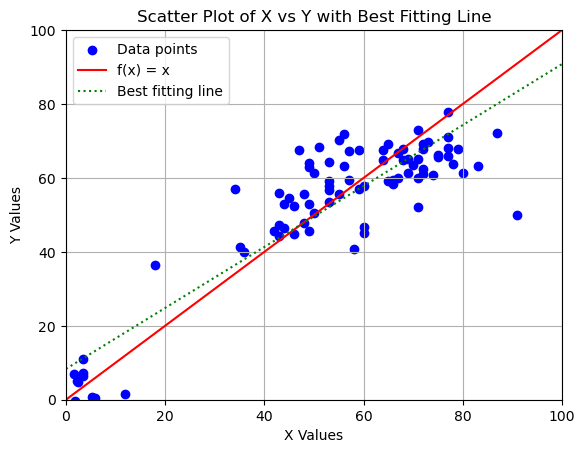

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Convert lists to NumPy arrays
y_test = np.array(y_test)
test_predictions = np.array(test_predictions)

# Reshape y_test for the model (it should be a 2D array)
y_test_reshaped = y_test.reshape(-1, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(y_test_reshaped, test_predictions)

# Generate values for the best fitting line
x_line = np.linspace(0, 100, 400).reshape(-1, 1)
y_line = model.predict(x_line)

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')

# Add the f(x) = x line (identity line)
plt.plot(x_line, x_line, color='red', label='f(x) = x')

# Plot the best-fitting line from linear regression
plt.plot(x_line, y_line, color='green', label='Best fitting line', linestyle=':')

# Add labels and title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title('Scatter Plot of X vs Y with Best Fitting Line')
plt.xlim(0, 100)  # Set the limits for x-axis
plt.ylim(0, 100)  # Set the limits for y-axis
plt.legend()

# Show plot
plt.grid(True)
plt.show()